In [19]:
import os
os.environ["R_HOME"] = r"C:\Program Files\R\R-4.6.1"
os.environ["PATH"] = r"C:\Program Files\R\R-4.6.1\bin\x64;" + os.environ["PATH"]

from pymer4.models import lmer

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler
from itertools import chain, combinations
import pyarrow

In [21]:
def powerset(iterable):
    "powerset([1,2,3]) --> () (1,) (2,) (3,) (1,2) (1,3) (2,3) (1,2,3)"
    return chain.from_iterable(combinations(iterable, r) for r in range(len(iterable)+1))

In [22]:
df = pd.read_csv('./new_dataset/dataset_for_R.csv', sep = ';', encoding='latin1')

In [23]:
## rename some columns
df.rename(columns={'fracture_hip fracture': 'fracture_hip', 
                   'fracture_hip replacement': 'fracture_hip_replacement',
                   'fracture_pelvis fracture': 'fracture_pelvis',
                    'ethnicity_south asian': 'ethnicity_south_asian'}, inplace=True)

In [24]:
x_col =    [#'participant',
            #'timestamp',
            #'clinical-timestamp',
            #'sis-01',
            #'sis-02',  
            #'sis-03',
            #'sis-04',
            #'sis-05',
            #'sis-06',
            #'sis',   ## response num
            #'ohs-01',
            #'ohs-02',
            #'ohs-03',
            #'ohs-04',
            #'ohs-05',
            #'ohs-06',
            #'ohs-07',
            #'ohs-08',
            #'ohs-09',
            #'ohs-10',
            #'ohs-11',
            #'ohs-12',
            #'ohs',    ## response num
            #'oks-01',
            #'oks-02',
            #'oks-03',
            #'oks-04',
            #'oks-05',
            #'oks-06',
            #'oks-07',
            #'oks-08',
            #'oks-09',
            #'oks-10',
            #'oks-11',
            #'oks-12',
            #'oks',   ## response num
            #'tug',
            #'chairstand',
            #'acceleration-count',    ### correlation between acceleration-count and acceleration-sum : 0.9951972186352874
            'acceleration-mean',
            'acceleration-std',
            'acceleration-sum',
            'acceleration-entropy',
            'acceleration-kurtosis',
            #'acceleration-skew',    ### correlation between acceleration-kurtosis and acceleration-skew : 0.8125826802627331
            #'acceleration-coefficient-of-variation',   ### correlation between acceleration-std and acceleration-coefficient-of-variation : 0.9981691376357329
            'acceleration-minutes-with-data',
            #'acceleration-hours-with-data',    ### correlation between acceleration-minutes-with-data and acceleration-hours-with-data : 0.9641458619672144
            'acceleration-movement-events-00to06',
            'acceleration-movement-events-06to12',
            'acceleration-movement-events-12to18',
            'acceleration-movement-events-18to24',
            'acceleration-movement-events-24h',
            'acceleration-intradaily-variability',
            #'heartrate-count',               ### correlation between heartrate-count and step-count : 0.876279182684799
            'heartrate-min',
            'heartrate-max',
            'heartrate-mean',
            'heartrate-std',
            #'heartrate-hours-with-data',            ### correlation between heartrate-hours-with-data and step-ratio : 0.8663971705294171
            'motion-count',
            'motion-ratio',
            #'motion-mean',      ### correlation between motion-count and motion-mean : 0.9857676696532148   (prefer total per day than average[motion per hour] in the day)
            #'motion-max',       ### correlation between motion-count and motion-max : 0.8091784342142361
            'motion-max-timestamp',
            #'position-count',    ### correlation between position-count and position-duration : 0.8047174777969475
            'position-duration',
            'position-distance-travelled',
            'sleep-total',
            'sleep-deep',
            #'sleep-light',    ### correlation between sleep-total and sleep-light : 0.7930157798362605
            'sleep-rem',
            'sleep-snoring',
            'sleep-duration-to-sleep',
            'sleep-duration-to-wakeup',
            'sleep-wakeup-count',
            'sleep-heartrate-mean',
            'sleep-heartrate-min',
            #'sleep-heartrate-max',    ### correlation between sleep-heartrate-mean and sleep-heartrate-max : 0.7302037341830914
            'step-count',
            'step-ratio',
            #'step-mean',             ### correlation between step-mean and step-count : 0.9205297140077597
            #'step-max',              ### correlation between step-count and step-max : 0.9586093567130545   (prefer total steps per day than max[steps per hour] in the day))
            'step-max-timestamp',
            'age',
            'sex_male',
            'education_label',
            'work_part_time',
            #'fracture_femur fracture',  ### VIF high (BASELINE)
            'fracture_hip',              ### renamed from 'fracture_hip fracture',
            'fracture_hip_replacement',  ### renamed from 'fracture_hip replacement'
            'fracture_pelvis',  ### renamend from 'fracture_pelvis fracture'
            'ethnicity_black',
            #'ethnicity_caucasian',   correlation between ethnicity_black and ethnicity_caucasian : -0.7905694150420951 (BASELINE)
            'ethnicity_south_asian'   ### renamed from 'ethnicity_south asian'
            #'SISS_Category_Q',   ## response class quartile
            #'OHSS_Category_Q',   ## response class quartile
            #'OKSS_Category_Q'   ## response class quartile
            ]

In [25]:
X = df[x_col]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns)

In [26]:
len(x_col)

42

In [27]:
#combo = powerset(X.columns)
#c_list = list(combo)
#combo_col = []

In [28]:
#for tup in c_list:
#    lista_col = list(tup)
    #summa = '+'.join(tup)
#    combo_col.append(lista_col)

#print(len(combo_col))

In [29]:
col_resp = ['sis', 'ohs', 'oks', 'SISS_Category_Q', 'OHSS_Category_Q', 'OKSS_Category_Q']

In [30]:
import polars as pl

data_pd = pd.concat([df[['participant'] + col_resp], X_scaled], axis=1)
# pymer4 0.9 richiede polars (non pandas)
data = pl.from_pandas(data_pd)

In [31]:
def bt(name):
    """Backtick-quote names with hyphens/spaces for R formulas."""
    return f'`{name}`'

for col in col_resp:
    lista_results = []

    for pred_col in x_col:
        formula = f'{bt(col)} ~ {bt(pred_col)} + (1 + {bt(pred_col)}|participant)'
        

        try: 
            model = lmer(formula, data=data)
            model.fit(summary=False)
            aic = model.result_fit_stats['AIC'].item()

            # p-value del fixed effect (escludi Intercept)
            fit_df = model.result_fit.to_pandas() if hasattr(model.result_fit, 'to_pandas') else model.result_fit
            if 'term' in fit_df.columns:
                row = fit_df.loc[fit_df['term'].astype(str).str.replace('`', '') == pred_col]
            else:
                row = fit_df.iloc[[1]]  # tipicamente intercept=0, pred=1

            pcol = next((c for c in ['p_value', 'p.value', 'Pr(>|t|)', 'pval'] if c in fit_df.columns), None)
            p_value = float(row[pcol].iloc[0]) if pcol is not None and len(row) else None     ### p-value effetto fisso

            # Estrai il coefficiente del pred_col
            coef_col = next((c for c in ['Estimate', 'estimate', 'coef', 'coeff', 'Coefficient'] if c in fit_df.columns), None)
            coef = float(row[coef_col].iloc[0]) if coef_col is not None and len(row) else None

            lista_results.append([pred_col, coef, p_value, aic])
        except Exception as e:
            lista_results.append([pred_col, None, None, None])
            print(f'Skip {formula}: {e}')

    out = (
        pd.DataFrame(lista_results, columns=['predictors', 'coeff', 'p_value', 'aic'])
        .sort_values(by='aic', ascending=True)  # AIC più basso = meglio
    )
    out.to_csv(f'./new_results/mixed_models/lmm_{col}_AIC.csv', index=False, sep=';')
    print(f'Saved lmm_{col}_AIC.csv')

R messages: 
boundary (singular) fit: see help('isSingular')

Random effect variances not available. Returned R2 does not account for random effects.

R messages: 
boundary (singular) fit: see help('isSingular')

Random effect variances not available. Returned R2 does not account for random effects.

R messages: 
Convergence status
: [1] FALSE
attr(,"gradient")
[1] 0.002498742

R messages: 
boundary (singular) fit: see help('isSingular')

Random effect variances not available. Returned R2 does not account for random effects.

R messages: 
boundary (singular) fit: see help('isSingular')

Random effect variances not available. Returned R2 does not account for random effects.

R messages: 
boundary (singular) fit: see help('isSingular')

Random effect variances not available. Returned R2 does not account for random effects.

R messages: 
boundary (singular) fit: see help('isSingular')

Random effect variances not available. Returned R2 does not account for random effects.

Skip `sis` ~ `e

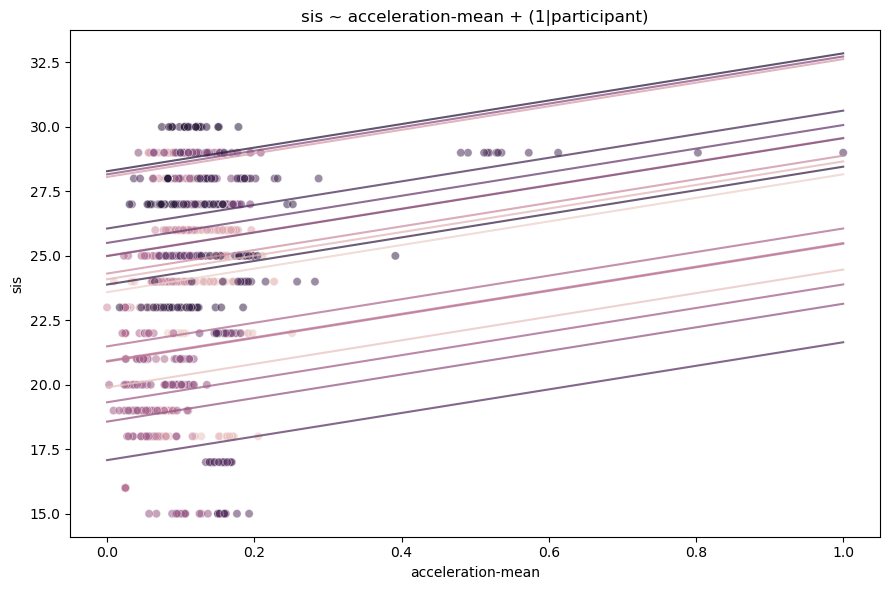

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

# --- scegli predictor / response ---
chosen_predictor = 'acceleration-mean'
chosen_response = 'sis'

# 1) Fit LMM (come m5 <- ... in glmm_PRD_v2.R)
formula = f'{bt(chosen_response)} ~ {bt(chosen_predictor)} + (1|participant)'
model = lmer(formula, data=data)
model.fit(summary=False)

df_plot = data.to_pandas()

# 2) Griglia di predizione per ogni participant
#    (stesso schema R: seq(...) + loop sui livelli del grouping factor)
x_min = df_plot[chosen_predictor].min()
x_max = df_plot[chosen_predictor].max()
x_seq = np.linspace(x_min, x_max, 100)
participants = df_plot['participant'].dropna().unique()

newdata = pd.concat(
    [
        pd.DataFrame({chosen_predictor: x_seq, 'participant': p})
        for p in participants
    ],
    ignore_index=True,
)

# 3) Predizioni con random effects (come predict(..., allow.new.levels=TRUE))
newdata['predicted'] = model.predict(pl.from_pandas(newdata), use_rfx=True)

# 4) Plot: punti osservati + curve predette per participant
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_plot,
    x=chosen_predictor,
    y=chosen_response,
    hue='participant',
    alpha=0.55,
    legend=False,
)
sns.lineplot(
    data=newdata,
    x=chosen_predictor,
    y='predicted',
    hue='participant',
    legend=False,
    alpha=0.75,
    lw=1.5,
)
plt.xlabel(chosen_predictor)
plt.ylabel(chosen_response)
plt.title(f'{chosen_response} ~ {chosen_predictor} + (1|participant)')
plt.tight_layout()
plt.show()


In [33]:
x_col

['acceleration-mean',
 'acceleration-std',
 'acceleration-sum',
 'acceleration-entropy',
 'acceleration-kurtosis',
 'acceleration-minutes-with-data',
 'acceleration-movement-events-00to06',
 'acceleration-movement-events-06to12',
 'acceleration-movement-events-12to18',
 'acceleration-movement-events-18to24',
 'acceleration-movement-events-24h',
 'acceleration-intradaily-variability',
 'heartrate-min',
 'heartrate-max',
 'heartrate-mean',
 'heartrate-std',
 'motion-count',
 'motion-ratio',
 'motion-max-timestamp',
 'position-duration',
 'position-distance-travelled',
 'sleep-total',
 'sleep-deep',
 'sleep-rem',
 'sleep-snoring',
 'sleep-duration-to-sleep',
 'sleep-duration-to-wakeup',
 'sleep-wakeup-count',
 'sleep-heartrate-mean',
 'sleep-heartrate-min',
 'step-count',
 'step-ratio',
 'step-max-timestamp',
 'age',
 'sex_male',
 'education_label',
 'work_part_time',
 'fracture_hip',
 'fracture_hip_replacement',
 'fracture_pelvis',
 'ethnicity_black',
 'ethnicity_south_asian']

In [34]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
# --- scegli predictor / response ---
chosen_predictor = 'heartrate-max'
chosen_response = 'sis'
# 1) Fit LMM (come m5 <- ... in glmm_PRD_v2.R)
formula = f'{bt(chosen_response)} ~ {bt(chosen_predictor)} + (1 + {bt(chosen_predictor)}|participant)'
print(formula)
model = lmer(formula, data=data)
model.fit(summary=False)
df_plot = data.to_pandas()


`sis` ~ `heartrate-max` + (1 + `heartrate-max`|participant)


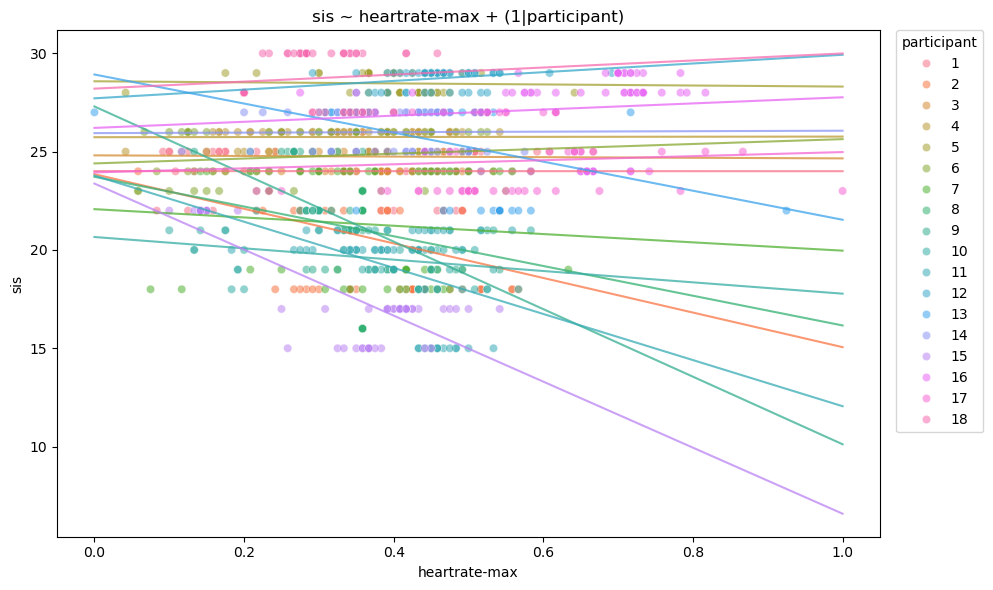

In [35]:
# 2) Griglia di predizione per ogni participant
#    (stesso schema R: seq(...) + loop sui livelli del grouping factor)
x_min = df_plot[chosen_predictor].min()
x_max = df_plot[chosen_predictor].max()
x_seq = np.linspace(x_min, x_max, 100)
participants = df_plot['participant'].dropna().unique()
newdata = pd.concat(
    [
        pd.DataFrame({chosen_predictor: x_seq, 'participant': p})
        for p in participants
    ],
    ignore_index=True,
)
# 3) Predizioni con random effects (come predict(..., allow.new.levels=TRUE))
newdata['predicted'] = model.predict(pl.from_pandas(newdata), use_rfx=True)
# 4) Plot: punti osservati + curve predette per participant
plt.figure(figsize=(9, 6))
palette = sns.color_palette("husl", len(participants))  # Cambia la paletta
scatter = sns.scatterplot(
    data=df_plot,
    x=chosen_predictor,
    y=chosen_response,
    hue='participant',
    alpha=0.55,
    legend='full',
    palette=palette,
)
line = sns.lineplot(
    data=newdata,
    x=chosen_predictor,
    y='predicted',
    hue='participant',
    legend=False,
    alpha=0.75,
    lw=1.5,
    palette=palette,
)
plt.xlabel(chosen_predictor)
plt.ylabel(chosen_response)
plt.title(f'{chosen_response} ~ {chosen_predictor} + (1|participant)')
plt.tight_layout()
plt.legend(title='participant', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.show()

In [36]:
# Visualizza il summary del modello
print(model.summary())

GT(_tbl_data=shape: (8, 10)
┌──────────────┬─────────────┬───────────┬───────────┬───┬───────────┬───────────┬─────────┬───────┐
│ rfx          ┆ param       ┆ estimate  ┆ std_error ┆ … ┆ t_stat    ┆ df        ┆ p_value ┆ stars │
│ ---          ┆ ---         ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---     ┆ ---   │
│ str          ┆ str         ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ str     ┆ str   │
╞══════════════╪═════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═════════╪═══════╡
│ participant- ┆ (Intercept) ┆ 2.489666  ┆ null      ┆ … ┆ null      ┆ null      ┆ null    ┆ null  │
│ sd           ┆             ┆           ┆           ┆   ┆           ┆           ┆         ┆       │
│ participant- ┆ `heartrate- ┆ 6.755438  ┆ null      ┆ … ┆ null      ┆ null      ┆ null    ┆ null  │
│ sd           ┆ max`        ┆           ┆           ┆   ┆           ┆           ┆         ┆       │
│ participant- ┆ (Intercept) ┆ -0.004575 ┆ null      ┆ … ┆ null